<div style="text-align:center">
    <span style="background: linear-gradient(to right, darkorange, navy);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           font-size: 32px;
           font-weight: bold;
           display: inline-block;">
        ✨Predicting Stellar Class
    </span>
</div>

![](https://www.kaggle.com/competitions/125222/images/header)

### <div style="color:white;background-color:navy;padding:1.2%;border-radius:12px 12px;font-size:1.0em;text-align:center">Playground Series ✨ Season 6 Episode 6</div> 

## <span style="color:navy;">✍️ A deeper look at the results</span>

- Participants in this challenge managed to get good scores using a variety of "Stacking" methods. However, it should be noted that some examples (rows) are extremely ambiguous and each framework assigns (guesses) a different class to these examples. Due to the very different answers (and lack of consensus), "Stacking" methods cannot solve this problem either, and the ambiguity remains.

- In this notebook, I first divide the test cases into four parts and name these four parts as follows:

  > 'Noon time'
  > 
  > 'Afternoon time'
  > 
  > 'Sunset time'  (Edge of Darkness)
  >
  > 'Night time'   (Darkness)
  >

- To do this segmentation in the samples, I compare the results of five independent notebooks (using different frameworks). That is, I vote between the five results for each row.

- 'Night time' (Darkness) is when the "Mode" iteration is two. In these examples, the ambiguity is very high. Two notebooks have detected the same class, but two other notebooks have detected a different class, and the last notebook has determined the third class.

- But the "Mode" iteration for 'Sunset time' (Edge of Darkness) is three. That means three notebooks predicted one class and two other notebooks predicted a different class. Even then, there is still a lot of ambiguity.

- The "Mode" repetition for 'Afternoon time' is four and the "Mode" repetition for 'Noon time' is five, and the probability of the results of these samples being correct is much higher in the "Stacking" method.

- So in the following I will only change the results of the 'Night time' examples which are very few and predicted by the "Stacking" method. I replaced the results of the independent CatBoost method because it is a good framework for this type of examples. Of course you may replace the results of the LightGBM framework or any other accurate method. In any case the results of the "Stacking" method are not the best solution for these examples.

- You can even replace the results for the 'Sunset time' samples (if watching the World Cup allows you to) with more accurate methods. Just never forget that the Public Score is calculated with 20% of the samples.


In [1]:
import numpy as np
import pandas as pd
import polars as pl
import typing, joblib
import os, re, gc, copy 
import time, json, random
from pathlib import Path
from tqdm import tqdm

# .................................................................
import seaborn as sns
from pprint import pprint
from matplotlib import colors
from colorama import Style, Fore
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# .................................................................
import scipy
import itertools
from ast import literal_eval
from itertools import product
from collections import Counter
from itertools import combinations
from itertools import permutations
from sympy.combinatorics import Permutation
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.fft import fft

# .................................................................
import warnings
warnings.filterwarnings('ignore')
!ls ../input/*/*/*

../input/competitions/playground-series-s6e6/sample_submission.csv
../input/competitions/playground-series-s6e6/test.csv
../input/competitions/playground-series-s6e6/train.csv

../input/notebooks/cdeotte/cat-v3-for-s6e6:
custom.css	    __output__.json    __results__.html  test_preds
__notebook__.ipynb  __results___files  subs		 train_oof

../input/notebooks/cdeotte/nn-v2-for-s6e6:
custom.css	    __output__.json   subs	  train_oof
__notebook__.ipynb  __results__.html  test_preds

../input/notebooks/cdeotte/realmlp-v5-for-s6e6:
custom.css	    __output__.json   subs	  train_oof
__notebook__.ipynb  __results__.html  test_preds

../input/notebooks/cdeotte/xgb-v5-for-s6e6:
custom.css	    __output__.json   test_preds  xgb-5_submission.csv
__notebook__.ipynb  __results__.html  train_oof

../input/notebooks/mehrankazeminia/s6e6-stellar-binary-chain:
custom.css	    __output__.json    __results__.html
__notebook__.ipynb  __results___files  submission_binary.csv

../input/notebooks/zoli800/s6e6-0-

## <span style="color:navy;">💫 Target | Class</span>

### <span style="color:skyblue;">For training data</span>

,Number,Percent
class,,
GALAXY,377480,0.653818
QSO,117143,0.202899
STAR,82724,0.143283


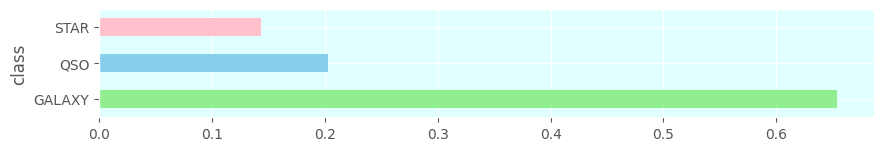

In [2]:
dtrain = pd.read_csv('../input/competitions/playground-series-s6e6/train.csv', index_col='id')

# ..............................................................................................
color = ['lightgreen','skyblue','pink']

plt.gca().set_facecolor('lightcyan')
dtrain['class'].value_counts(normalize=True).plot(kind='barh', figsize=(10,1.4), color=color);

pd.DataFrame(data= {'Number' : dtrain['class'].value_counts(), 
                    'Percent': dtrain['class'].value_counts(normalize=True)})

## <span style="color:navy;">💫 Data Information</span>

### <span style="color:skyblue;">Choosing five public notebooks for voting</span>

In [3]:
# ::::::::::::::::::::::::::::
# Thanks to: @cdeotte
# ::::::::::::::::::::::::::::
import1 = pd.read_csv('../input/notebooks/cdeotte/cat-v3-for-s6e6/subs/cat-3_submission.csv', index_col='id')
# Score:  0.96972 V1
import2 = pd.read_csv('../input/notebooks/cdeotte/realmlp-v5-for-s6e6/subs/realmlp-5_submission.csv', index_col='id')
# Score:  0.96979 V1
import3 = pd.read_csv('../input/notebooks/cdeotte/nn-v2-for-s6e6/subs/nn-2_submission.csv', index_col='id')
# Score:  0.96697 V1
import4 = pd.read_csv('../input/notebooks/cdeotte/xgb-v5-for-s6e6/xgb-5_submission.csv', index_col='id')
# Score:  0.96801 V1

# ::::::::::::::::::::::::::::
# S6E6 Stellar🪐Binary Chain
# ::::::::::::::::::::::::::::
import5 = pd.read_csv('../input/notebooks/mehrankazeminia/s6e6-stellar-binary-chain/submission_binary.csv', index_col='id')
# Score:  0.96666 V1

# ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
sub = pd.DataFrame(data= {'sub1' : import1['class'].values,
                          'sub2' : import2['class'].values,
                          'sub3' : import3['class'].values,
                          'sub4' : import4['class'].values,
                          'sub5' : import5['class'].values})
display(sub)

,sub1,sub2,sub3,sub4,sub5
0,GALAXY,GALAXY,GALAXY,GALAXY,GALAXY
1,GALAXY,GALAXY,GALAXY,GALAXY,GALAXY
2,GALAXY,GALAXY,GALAXY,GALAXY,GALAXY
3,STAR,STAR,STAR,STAR,STAR
4,GALAXY,GALAXY,GALAXY,GALAXY,GALAXY
...,...,...,...,...,...
247430,QSO,QSO,QSO,QSO,QSO
247431,QSO,QSO,QSO,QSO,QSO
247432,GALAXY,GALAXY,GALAXY,GALAXY,GALAXY
247433,QSO,QSO,QSO,QSO,QSO


# <span style="color:navy;">၊၊||၊ Explore the Results</span>
<p style="border-bottom: 12px solid darkorange"></p>
<p style="border-bottom: 3px solid navy"></p>

In [4]:
%%time
sub_n = sub.copy()
sub_n['sub1'] = sub['sub1'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})
sub_n['sub2'] = sub['sub2'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})
sub_n['sub3'] = sub['sub3'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})
sub_n['sub4'] = sub['sub4'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})
sub_n['sub5'] = sub['sub5'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})

mode = scipy.stats.mode(sub_n, axis=1)[0]
count = scipy.stats.mode(sub_n, axis=1)[1]

# ..................................................................
sub_n['mode']= mode
sub_n['count']= count
display(sub_n)

,sub1,sub2,sub3,sub4,sub5,mode,count
0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,5
2,0,0,0,0,0,0,5
3,2,2,2,2,2,2,5
4,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...
247430,1,1,1,1,1,1,5
247431,1,1,1,1,1,1,5
247432,0,0,0,0,0,0,5
247433,1,1,1,1,1,1,5


CPU times: user 188 ms, sys: 30.3 ms, total: 219 ms
Wall time: 221 ms


## <span style="color:navy;">💫 Voting Report</span>

,Number,Percent
count,,
5,239583,0.968266
4,4723,0.019088
3,3114,0.012585
2,15,0.000061


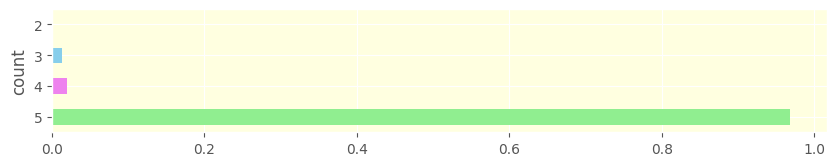

In [5]:
color= ['lightgreen','violet','skyblue','red']

plt.gca().set_facecolor('lightyellow')
sub_n['count'].value_counts(normalize=True).plot(kind='barh', figsize=(10,1.6), color=color);

pd.DataFrame(data= {'Number' : sub_n['count'].value_counts(), 
                    'Percent': sub_n['count'].value_counts(normalize=True)})

## <span style="color:navy;">💫 Splitting test samples</span>

In [6]:
positives5 = sub_n[sub_n['count']==5] # Noon
positives4 = sub_n[sub_n['count']==4] # Afternoon
positives3 = sub_n[sub_n['count']==3] # Sunset : Edge of Darkness
positives2 = sub_n[sub_n['count']==2] # Night : Darkness

# ..................................................................
display('Noon time', positives5.shape, positives5.head())
display('Afternoon time', positives4.shape, positives4.head())
display('Sunset time', positives3.shape, positives3.head())
display('Night time', positives2.shape, positives2.head())

'Noon time'

(239583, 7)

,sub1,sub2,sub3,sub4,sub5,mode,count
0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,5
2,0,0,0,0,0,0,5
3,2,2,2,2,2,2,5
4,0,0,0,0,0,0,5


'Afternoon time'

(4723, 7)

...

(3114, 7)

,sub1,sub2,sub3,sub4,sub5,mode,count
113,0,0,2,2,2,2,3
321,1,0,1,1,0,1,3
328,2,2,2,0,0,2,3
404,2,0,0,2,2,2,3
524,2,2,2,0,0,2,3


'Night time'

(15, 7)

,sub1,sub2,sub3,sub4,sub5,mode,count
5572,2,1,2,0,0,0,2
27437,1,0,0,2,2,0,2
35446,2,1,2,0,0,0,2
39743,1,1,2,0,2,1,2
47705,1,2,0,0,1,0,2


## <span style="color:navy;">💫 Best score of a public notebook</span>

### <span style="color:skyblue;">Via Stacking</span>

,Number,Percent
class,,
GALAXY,156941,0.634272
QSO,51453,0.207946
STAR,39041,0.157783


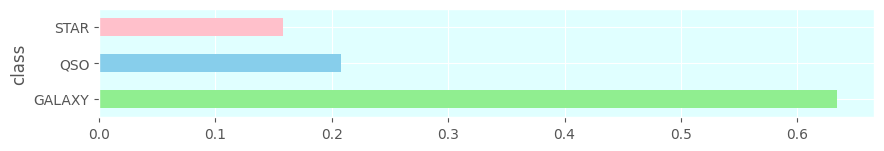

In [7]:
# Thanks to: @zoli800 | 0.97209 V2
sub_best = pd.read_csv('../input/notebooks/zoli800/s6e6-0-97209-clean-final/submission.csv', index_col='id')

# .............................................................................................................
color = ['lightgreen','skyblue','pink']

plt.gca().set_facecolor('lightcyan')
sub_best['class'].value_counts(normalize=True).plot(kind='barh', figsize=(10,1.4), color=color);

pd.DataFrame(data= {'Number' : sub_best['class'].value_counts(), 
                    'Percent': sub_best['class'].value_counts(normalize=True)})

## <span style="color:navy;">💫 Replace and Submission</span>

In [8]:
%%time
sub_n['best'] = sub_best['class'].values
sub_n['best'] = sub_n['best'].map({'GALAXY': 0,'QSO': 1,'STAR': 2})

# ..............................................................................................
for i in range(sub_n.shape[0]):
    
    if (sub_n['count'][i]== 2):
        sub_n['best'][i]= sub_n['sub4'][i]
        
# ..............................................................................................
sub_sample = pd.read_csv('../input/competitions/playground-series-s6e6/sample_submission.csv') 

sub_sample['class']= sub_n['best'].map({0:'GALAXY', 1:'QSO', 2:'STAR'})
sub_sample.to_csv('submission.csv', index=False)

# Score: 0.97214
sub_sample.head()

CPU times: user 1.31 s, sys: 10.6 ms, total: 1.32 s
Wall time: 1.34 s


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
